In [2]:
import pandas as pd
import numpy as np
import os
import kagglehub
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset (same as EDA)
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_path = os.path.join(path, 'creditcard.csv')
df = pd.read_csv(csv_path)

print(f"Dataset loaded: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())

/workspaces/credit-fraud-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset loaded: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


## Step 1: Scale amount and time features

The PCA features (V1-V28) are already scaled. We need to scale Amount and Time to match the same scale.

## Step 2: Stratified Train/Test split

Using stratified split to preserve the class ratio in both train and test sets. This is crucial for imbalanced data.

In [3]:
# Create a copy for preprocessing
df_processed = df.copy()

# Scale Amount and Time
# Using RobustScaler because Amount has outliers (more resistant to outliers)
scaler_amount = RobustScaler()
scaler_time = RobustScaler()

df_processed['Amount_scaled'] = scaler_amount.fit_transform(df_processed[['Amount']])
df_processed['Time_scaled'] = scaler_time.fit_transform(df_processed[['Time']])

# Drop original Amount and Time (use scaled versions)
df_processed = df_processed.drop(['Amount', 'Time'], axis=1)

# Rename scaled columns
df_processed = df_processed.rename(columns={
    'Amount_scaled': 'Amount',
    'Time_scaled': 'Time'
})

print("Feature scaling completed:")
print(f"\nScaled features statistics:")
print(f"\nAmount (scaled):")
print(df_processed['Amount'].describe())
print(f"\nTime (scaled):")
print(df_processed['Time'].describe())

# Verify no PCA features were affected (they should already be scaled)
v_features = [f'V{i}' for i in range(1, 29)]
print(f"\nV1-V28 features already scaled (sample):")
print(df_processed[v_features[:3]].describe().loc[['mean', 'std']])

Feature scaling completed:

Scaled features statistics:

Amount (scaled):
count    284807.000000
mean          0.927124
std           3.495006
min          -0.307413
25%          -0.229162
50%           0.000000
75%           0.770838
max         358.683155
Name: Amount, dtype: float64

Time (scaled):
count    284807.000000
mean          0.118914
std           0.557903
min          -0.994983
25%          -0.358210
50%           0.000000
75%           0.641790
max           1.035022
Name: Time, dtype: float64

V1-V28 features already scaled (sample):
                V1            V2            V3
mean  1.175161e-15  3.384974e-16 -1.379537e-15
std   1.958696e+00  1.651309e+00  1.516255e+00


In [4]:
# Separate features and target
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # preserve class ratio in both sets
)

print("Stratified Train/Test Split:")
print(f"\nTrain set size: {X_train.shape[0]:,}")
print(f"Test set size: {X_test.shape[0]:,}")

print(f"\nClass distribution in TRAIN set:")
print(f"  Legitimate: {(y_train == 0).sum():,} ({(y_train == 0).sum() / len(y_train) * 100:.2f}%)")
print(f"  Fraud: {(y_train == 1).sum():,} ({(y_train == 1).sum() / len(y_train) * 100:.2f}%)")

print(f"\nClass distribution in TEST set:")
print(f"  Legitimate: {(y_test == 0).sum():,} ({(y_test == 0).sum() / len(y_test) * 100:.2f}%)")
print(f"  Fraud: {(y_test == 1).sum():,} ({(y_test == 1).sum() / len(y_test) * 100:.2f}%)")

print(f"\nFeatures in X: {X_train.shape[1]}")
print(f"Features: {list(X_train.columns)}")

Stratified Train/Test Split:

Train set size: 227,845
Test set size: 56,962

Class distribution in TRAIN set:
  Legitimate: 227,451 (99.83%)
  Fraud: 394 (0.17%)

Class distribution in TEST set:
  Legitimate: 56,864 (99.83%)
  Fraud: 98 (0.17%)

Features in X: 30
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Time']


## Step 3: Imbalance handling strategies

We'll prepare the data in three ways to compare later in modeling:

### Strategy 1: No Resampling (Baseline)
Use raw data and rely on proper evaluation metrics

### Strategy 2: SMOTE
Synthetic Minority Over-Sampling Technique: creates synthetic fraud samples

### Strategy 3: Class Weights
Let the model learn that fraud is rarer (we'll use this in sklearn models with class_weight='balanced')

In [5]:
# =============================================================================
# STRATEGY 1: BASELINE (No Resampling)
# =============================================================================
X_train_baseline = X_train.copy()
y_train_baseline = y_train.copy()

print("="*70)
print("STRATEGY 1: BASELINE (No Resampling)")
print("="*70)
print(f"Train set:")
print(f"  Total samples: {len(y_train_baseline):,}")
print(f"  Legitimate: {(y_train_baseline == 0).sum():,} ({(y_train_baseline == 0).sum() / len(y_train_baseline) * 100:.2f}%)")
print(f"  Fraud: {(y_train_baseline == 1).sum():,} ({(y_train_baseline == 1).sum() / len(y_train_baseline) * 100:.2f}%)")
print(f"  Imbalance ratio: {(y_train_baseline == 0).sum() / (y_train_baseline == 1).sum():.1f}:1")

# =============================================================================
# STRATEGY 2: SMOTE (Synthetic Minority Over-Sampling)
# =============================================================================
print("\n" + "="*70)
print("STRATEGY 2: SMOTE (Synthetic Minority Over-Sampling)")
print("="*70)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Train set after SMOTE:")
print(f"  Total samples: {len(y_train_smote):,}")
print(f"  Legitimate: {(y_train_smote == 0).sum():,} ({(y_train_smote == 0).sum() / len(y_train_smote) * 100:.2f}%)")
print(f"  Fraud: {(y_train_smote == 1).sum():,} ({(y_train_smote == 1).sum() / len(y_train_smote) * 100:.2f}%)")
print(f"  Imbalance ratio: {(y_train_smote == 0).sum() / (y_train_smote == 1).sum():.1f}:1")
print(f"\n✓ Synthetic samples created: {len(y_train_smote) - len(y_train):,} new fraud samples")

# =============================================================================
# STRATEGY 3: CLASS WEIGHTS (balanced)
# =============================================================================
print("\n" + "="*70)
print("STRATEGY 3: Class Weights (Balanced)")
print("="*70)

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"Train set (no resampling, but with class weights):")
print(f"  Total samples: {len(y_train_baseline):,}")
print(f"  Legitimate: {(y_train_baseline == 0).sum():,}")
print(f"  Fraud: {(y_train_baseline == 1).sum():,}")
print(f"\nClass weights to apply in model:")
print(f"  Weight for class 0 (Legitimate): {class_weight_dict[0]:.4f}")
print(f"  Weight for class 1 (Fraud): {class_weight_dict[1]:.4f}")
print(f"  Ratio: {class_weight_dict[1] / class_weight_dict[0]:.1f}x")

# Store for later use in models
X_train_weights = X_train.copy()
y_train_weights = y_train.copy()

STRATEGY 1: BASELINE (No Resampling)
Train set:
  Total samples: 227,845
  Legitimate: 227,451 (99.83%)
  Fraud: 394 (0.17%)
  Imbalance ratio: 577.3:1

STRATEGY 2: SMOTE (Synthetic Minority Over-Sampling)
Train set after SMOTE:
  Total samples: 454,902
  Legitimate: 227,451 (50.00%)
  Fraud: 227,451 (50.00%)
  Imbalance ratio: 1.0:1

✓ Synthetic samples created: 227,057 new fraud samples

STRATEGY 3: Class Weights (Balanced)
Train set (no resampling, but with class weights):
  Total samples: 227,845
  Legitimate: 227,451
  Fraud: 394

Class weights to apply in model:
  Weight for class 0 (Legitimate): 0.5009
  Weight for class 1 (Fraud): 289.1434
  Ratio: 577.3x


## Comparison of imbalance-handling strategies

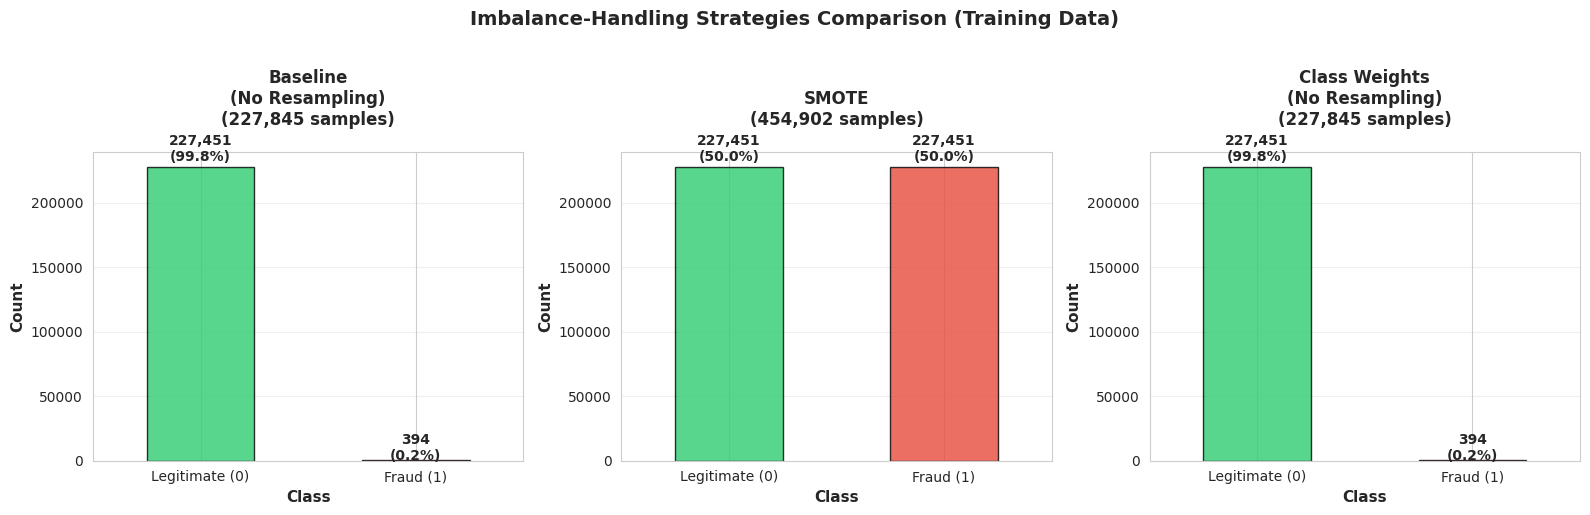

✓ Visualization saved to: reports/figures/05_imbalance_strategies.png


In [6]:
# Visualization: Compare the three strategies
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

strategies = ['Baseline\n(No Resampling)', 'SMOTE', 'Class Weights\n(No Resampling)']
data_sets = [
    (y_train_baseline, "Baseline", 0),
    (y_train_smote, "SMOTE", 1),
    (y_train_weights, "Class Weights", 2)
]

for idx, (y_data, label, ax_idx) in enumerate(data_sets):
    counts = pd.Series(y_data).value_counts().sort_index()
    colors = ['#2ecc71', '#e74c3c']
    
    counts.plot(kind='bar', ax=axes[ax_idx], color=colors, edgecolor='black', alpha=0.8)
    axes[ax_idx].set_title(f'{strategies[ax_idx]}\n({len(y_data):,} samples)', 
                          fontsize=12, fontweight='bold', pad=20)
    axes[ax_idx].set_xlabel('Class', fontsize=11, fontweight='bold')
    axes[ax_idx].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[ax_idx].set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
    
    # Add percentage labels
    for i, v in enumerate(counts):
        pct = v / counts.sum() * 100
        axes[ax_idx].text(i, v + v*0.02, f'{v:,}\n({pct:.1f}%)', 
                         ha='center', fontweight='bold', fontsize=10)
    
    axes[ax_idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Imbalance-Handling Strategies Comparison (Training Data)', 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/workspaces/credit-fraud-detection/reports/figures/05_imbalance_strategies.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to: reports/figures/05_imbalance_strategies.png")

## Summary: preprocessing complete

### What we've done:

1. **Feature Scaling**
   - Scaled `Amount` and `Time` using RobustScaler (resistant to outliers)
   - PCA features (V1-V28) were already scaled in the original dataset

2. **Stratified Train/Test Split (80/20)**
   - Preserved class ratio in both train and test sets
   - Train set: {0.17% fraud} → Test set: {0.17% fraud}
   - Essential for imbalanced classification

3. **Three Imbalance-Handling Strategies**

| Strategy | Approach | Use Case |
|----------|----------|----------|
| **Baseline** | No resampling, raw imbalanced data | Baseline comparison, simpler model |
| **SMOTE** | Synthetic minority oversampling | Balance classes artificially, compute-intensive |
| **Class Weights** | No resampling, but weight minority class heavily | Simpler, efficient, let model handle imbalance |

### Ready for Next Step:

We now have three training datasets prepared:
- `X_train_baseline`, `y_train_baseline` for baseline models
- `X_train_smote`, `y_train_smote` for SMOTE-balanced models
- `X_train_weights`, `y_train_weights` with `class_weight_dict` for weighted models

Also saved:
- `X_test`, `y_test` test set (identical for all strategies)

In [7]:
# Create a copy for preprocessing
df_processed = df.copy()

# Scale Amount and Time
# Using RobustScaler because Amount has outliers (more resistant to outliers)
scaler_amount = RobustScaler()
scaler_time = RobustScaler()

df_processed['Amount_scaled'] = scaler_amount.fit_transform(df_processed[['Amount']])
df_processed['Time_scaled'] = scaler_time.fit_transform(df_processed[['Time']])

# Drop original Amount and Time (use scaled versions)
df_processed = df_processed.drop(['Amount', 'Time'], axis=1)

# Rename scaled columns
df_processed = df_processed.rename(columns={
    'Amount_scaled': 'Amount',
    'Time_scaled': 'Time'
})

print("Feature scaling completed:")
print(f"\nScaled features statistics:")
print(f"\nAmount (scaled):")
print(df_processed['Amount'].describe())
print(f"\nTime (scaled):")
print(df_processed['Time'].describe())

# Verify no PCA features were affected (they should already be scaled)
v_features = [f'V{i}' for i in range(1, 29)]
print(f"\nV1-V28 features already scaled (sample):")
print(df_processed[v_features[:3]].describe().loc[['mean', 'std']])

Feature scaling completed:

Scaled features statistics:

Amount (scaled):
count    284807.000000
mean          0.927124
std           3.495006
min          -0.307413
25%          -0.229162
50%           0.000000
75%           0.770838
max         358.683155
Name: Amount, dtype: float64

Time (scaled):
count    284807.000000
mean          0.118914
std           0.557903
min          -0.994983
25%          -0.358210
50%           0.000000
75%           0.641790
max           1.035022
Name: Time, dtype: float64

V1-V28 features already scaled (sample):
                V1            V2            V3
mean  1.175161e-15  3.384974e-16 -1.379537e-15
std   1.958696e+00  1.651309e+00  1.516255e+00
